# ¿Pueden los datos predecir el futuro cripto?
## Machine Learning aplicado a 23 Criptomonedas

---

**Momento 3 — Evento Evaluativo 3 | Minería de Datos**

---

### El contexto

En los últimos años, las criptomonedas han pasado de ser un fenómeno marginal a convertirse en una clase de activos que mueve **billones de dólares** diariamente. Bitcoin, Ethereum, Cardano... cada moneda tiene su propia historia, sus picos de euforia y sus caídas dramáticas.

La pregunta que millones de inversores se hacen todos los días es siempre la misma:

> *"¿Subirá o bajará mañana?"*

### La apuesta

En este análisis usamos **Machine Learning** para intentar responder esa pregunta a partir de patrones históricos de **23 criptomonedas**. No buscamos una bola de cristal — buscamos entender qué señales del mercado tienen valor predictivo real.

### Pregunta de investigación

**¿Es posible predecir si el precio de cierre de una criptomoneda subirá o bajará al día siguiente, usando únicamente indicadores técnicos históricos disponibles antes de esa fecha?**

### Metodología (CRISP-DM)

| Fase | Contenido |
|------|----------|
| 1. Comprensión del negocio | Predicción de dirección de precios cripto |
| 2. Comprensión de los datos | 23 CSVs con datos OHLCV históricos |
| 3. Preparación de datos | Feature engineering técnico |
| 4. Modelado | Árbol de Decisión (Clasificación + Regresión) |
| 5. Evaluación | Accuracy, Matriz de Confusión, MAE, R² |
| 6. Despliegue | Conclusiones e interpretación de negocio |


---
## Parte 1: Importar Librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
import os
import warnings

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

print('Librerías importadas correctamente')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')


Librerías importadas correctamente
  pandas  : 2.3.2
  numpy   : 2.3.2


---
## Parte 2: Carga y Exploración de Datos

El dataset contiene datos históricos de precio (Open, High, Low, Close), volumen y capitalización de mercado para **23 criptomonedas**. Los datos provienen de registros diarios recopilados desde los inicios de cada moneda hasta 2021.


In [2]:
# Cargar todos los archivos CSV
DATA_PATH = './Cryptocurrency_Historical_Prices/'
csv_files = sorted(glob.glob(DATA_PATH + 'coin_*.csv'))

print(f'Archivos CSV encontrados: {len(csv_files)}')
for f in csv_files:
    print(f'  {os.path.basename(f)}')


Archivos CSV encontrados: 23
  coin_Aave.csv
  coin_BinanceCoin.csv
  coin_Bitcoin.csv
  coin_Cardano.csv
  coin_ChainLink.csv
  coin_Cosmos.csv
  coin_CryptocomCoin.csv
  coin_Dogecoin.csv
  coin_EOS.csv
  coin_Ethereum.csv
  coin_Iota.csv
  coin_Litecoin.csv
  coin_Monero.csv
  coin_NEM.csv
  coin_Polkadot.csv
  coin_Solana.csv
  coin_Stellar.csv
  coin_Tether.csv
  coin_Tron.csv
  coin_USDCoin.csv
  coin_Uniswap.csv
  coin_WrappedBitcoin.csv
  coin_XRP.csv


In [3]:
# Combinar todos los archivos en un único DataFrame
all_dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
# Reemplazar volumen 0 por NaN (datos faltantes en registros antiguos)
df_raw['Volume'] = df_raw['Volume'].replace(0, np.nan)

print('=== DATASET COMBINADO ===')
print(f'Total de registros : {len(df_raw):,}')
print(f'Criptomonedas      : {df_raw["Name"].nunique()}')
print(f'Columnas           : {list(df_raw.columns)}')
print(f'Rango de fechas    : {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}')
print()
print('Tipos de datos:')
print(df_raw.dtypes)
print()
print('Valores nulos:')
print(df_raw.isnull().sum())


=== DATASET COMBINADO ===
Total de registros : 37,082
Criptomonedas      : 23
Columnas           : ['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap']
Rango de fechas    : 2013-04-29 → 2021-07-06

Tipos de datos:
SNo                   int64
Name                 object
Symbol               object
Date         datetime64[ns]
High                float64
Low                 float64
Open                float64
Close               float64
Volume              float64
Marketcap           float64
dtype: object

Valores nulos:
SNo            0
Name           0
Symbol         0
Date           0
High           0
Low            0
Open           0
Close          0
Volume       640
Marketcap      0
dtype: int64


In [4]:
# Resumen estadístico por moneda
summary = df_raw.groupby('Name').agg(
    registros=('Date', 'count'),
    inicio=('Date', 'min'),
    fin=('Date', 'max'),
    precio_maximo=('High', 'max'),
    precio_minimo=('Low', 'min'),
    precio_promedio_cierre=('Close', 'mean')
).reset_index()

summary['inicio'] = summary['inicio'].dt.date
summary['fin'] = summary['fin'].dt.date
summary['precio_maximo'] = summary['precio_maximo'].apply(lambda x: f'${x:,.2f}')
summary['precio_promedio_cierre'] = summary['precio_promedio_cierre'].apply(lambda x: f'${x:,.2f}')

print('Resumen por criptomoneda:')
print(summary.to_string(index=False))


Resumen por criptomoneda:
           Name  registros     inicio        fin precio_maximo  precio_minimo precio_promedio_cierre
           Aave        275 2020-10-05 2021-07-06       $666.86      25.966155                $255.53
   Binance Coin       1442 2017-07-26 2021-07-06       $690.93       0.096109                 $52.25
        Bitcoin       2991 2013-04-29 2021-07-06    $64,863.10      65.526001              $6,711.29
        Cardano       1374 2017-10-02 2021-07-06         $2.46       0.017620                  $0.26
      Chainlink       1385 2017-09-21 2021-07-06        $52.88       0.126297                  $6.31
         Cosmos        845 2019-03-15 2021-07-06        $32.14       1.130963                  $6.77
Crypto.com Coin        935 2018-12-15 2021-07-06         $0.27       0.011487                  $0.08
       Dogecoin       2760 2013-12-16 2021-07-06         $0.74       0.000085                  $0.01
            EOS       1466 2017-07-02 2021-07-06        $22.89   

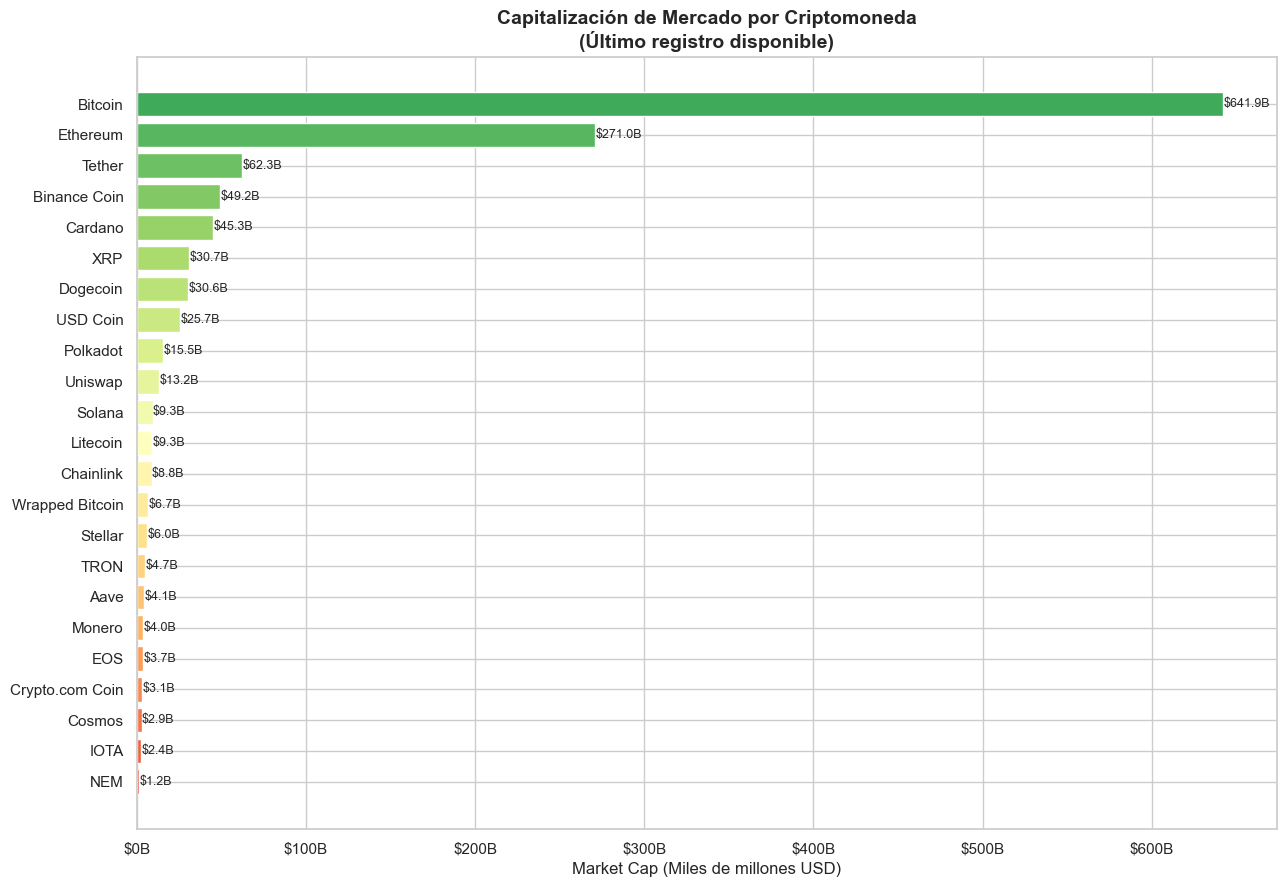

Figura guardada: 01_market_cap.png


In [5]:
# Visualización 1: Capitalización de mercado
df_latest = df_raw.sort_values('Date').groupby('Name').last().reset_index()
df_latest = df_latest[df_latest['Marketcap'] > 0].sort_values('Marketcap', ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(df_latest)))
bars = ax.barh(df_latest['Name'], df_latest['Marketcap'] / 1e9, color=colors, edgecolor='white')

ax.set_xlabel('Market Cap (Miles de millones USD)', fontsize=12)
ax.set_title('Capitalización de Mercado por Criptomoneda\n(Último registro disponible)', 
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

for bar, val in zip(bars, df_latest['Marketcap'] / 1e9):
    if val > 0.5:
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'${val:.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_market_cap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 01_market_cap.png')


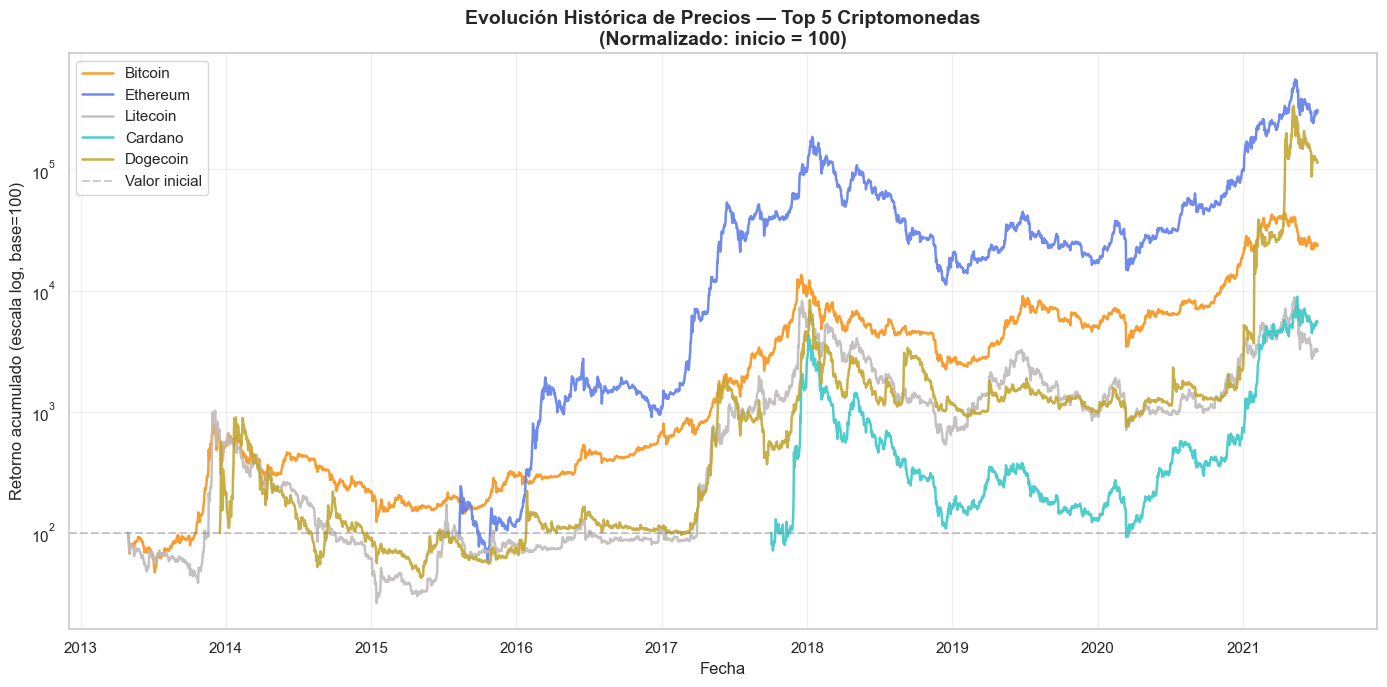

Figura guardada: 02_price_history.png


In [6]:
# Visualización 2: Evolución histórica de precios (normalizada)
monedas_destacadas = ['Bitcoin', 'Ethereum', 'Litecoin', 'Cardano', 'Dogecoin']
colores = ['#F7931A', '#627EEA', '#BFBBBB', '#3CC8C8', '#C2A633']

fig, ax = plt.subplots(figsize=(14, 7))

for name, color in zip(monedas_destacadas, colores):
    df_coin = df_raw[df_raw['Name'] == name].sort_values('Date').copy()
    if len(df_coin) == 0:
        continue
    normalized = df_coin['Close'] / df_coin['Close'].iloc[0] * 100
    ax.plot(df_coin['Date'], normalized, label=name, color=color, linewidth=1.8, alpha=0.9)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4, label='Valor inicial')
ax.set_yscale('log')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Retorno acumulado (escala log, base=100)', fontsize=12)
ax.set_title('Evolución Histórica de Precios — Top 5 Criptomonedas\n(Normalizado: inicio = 100)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 02_price_history.png')


---
## Parte 3: Ingeniería de Características (Feature Engineering)

Para predecir si el precio **subirá mañana**, necesitamos construir características que:
1. Estén disponibles **antes** del día que queremos predecir (sin data leakage)
2. Capturen señales relevantes del mercado

| Feature | Descripción | Fuente |
|---------|-------------|--------|
| `return_1d` | Retorno del día anterior (%) | Close t-1 / Close t-2 |
| `return_3d` | Retorno de los últimos 3 días | Close t-1 / Close t-4 |
| `return_7d` | Retorno de los últimos 7 días | Close t-1 / Close t-8 |
| `range_pct` | Rango de precio (High-Low)/Open del día anterior | Volatilidad |
| `vol_change` | Cambio porcentual en volumen | Actividad del mercado |
| `ma7_ratio` | Close / Media Móvil 7 días | Tendencia corto plazo |
| `ma30_ratio` | Close / Media Móvil 30 días | Tendencia largo plazo |
| `day_of_week` | Día de la semana (0=Lunes, 6=Domingo) | Estacionalidad |

**Target**: `1` si el precio de cierre de mañana será mayor que el de hoy, `0` si será menor.


In [7]:
def create_features(df):
    """Construye features técnicas para predicción. Sin data leakage: todos los valores
    se calculan con datos de días anteriores al que se quiere predecir."""
    df = df.sort_values('Date').reset_index(drop=True)

    # Retorno diario actual (para construir features del día anterior)
    df['return_today'] = df['Close'].pct_change()

    # Features del día anterior (.shift(1) = usar datos de ayer)
    df['return_1d'] = df['return_today'].shift(1)
    df['return_3d'] = df['Close'].pct_change(3).shift(1)
    df['return_7d'] = df['Close'].pct_change(7).shift(1)
    df['range_pct'] = ((df['High'] - df['Low']) / df['Open']).shift(1)
    df['vol_change'] = df['Volume'].pct_change().shift(1)

    # Medias móviles (calculadas con datos hasta ayer)
    ma7 = df['Close'].rolling(7).mean()
    ma30 = df['Close'].rolling(30).mean()
    df['ma7_ratio'] = (df['Close'] / ma7).shift(1)
    df['ma30_ratio'] = (df['Close'] / ma30).shift(1)

    # Día de la semana
    df['day_of_week'] = df['Date'].dt.dayofweek

    # Target clasificación: ¿Sube el precio MAÑANA?
    df['target_clf'] = (df['return_today'].shift(-1) > 0).astype(int)

    # Target regresión: ¿Cuánto cambia el precio MAÑANA?
    df['target_reg'] = df['return_today'].shift(-1)

    return df


# Aplicar a cada moneda por separado (para no mezclar series de tiempo)
processed = []
for name in df_raw['Name'].unique():
    df_coin = df_raw[df_raw['Name'] == name].copy()
    df_coin = create_features(df_coin)
    processed.append(df_coin)

df_feat = pd.concat(processed, ignore_index=True)

FEATURE_COLS = ['return_1d', 'return_3d', 'return_7d', 'range_pct',
                'vol_change', 'ma7_ratio', 'ma30_ratio', 'day_of_week']

# Limpiar infinitos y NaN
df_feat = df_feat.replace([np.inf, -np.inf], np.nan)
df_clean = df_feat.dropna(subset=FEATURE_COLS + ['target_clf', 'target_reg'])

print(f'Registros con features completas: {len(df_clean):,}')
print(f'Features usadas: {FEATURE_COLS}')
print()
print('Estadísticas de features:')
print(df_clean[FEATURE_COLS].describe().round(4))


Registros con features completas: 35,825
Features usadas: ['return_1d', 'return_3d', 'return_7d', 'range_pct', 'vol_change', 'ma7_ratio', 'ma30_ratio', 'day_of_week']

Estadísticas de features:
        return_1d   return_3d   return_7d   range_pct  vol_change   ma7_ratio  \
count  35825.0000  35825.0000  35825.0000  35825.0000  35825.0000  35825.0000   
mean       0.0042      0.0131      0.0333      0.0780      1.3103      1.0075   
std        0.0716      0.1383      0.2554      0.1164    118.4370      0.0959   
min       -0.4601     -0.5598     -0.5817      0.0000     -0.9999      0.5142   
25%       -0.0216     -0.0388     -0.0619      0.0310     -0.1920      0.9695   
50%        0.0000      0.0000      0.0000      0.0569     -0.0157      1.0000   
75%        0.0234      0.0439      0.0767      0.0979      0.2098      1.0333   
max        3.5557      5.6358      8.0881     15.1921  19769.7644      3.1416   

       ma30_ratio  day_of_week  
count  35825.0000   35825.0000  
mean      

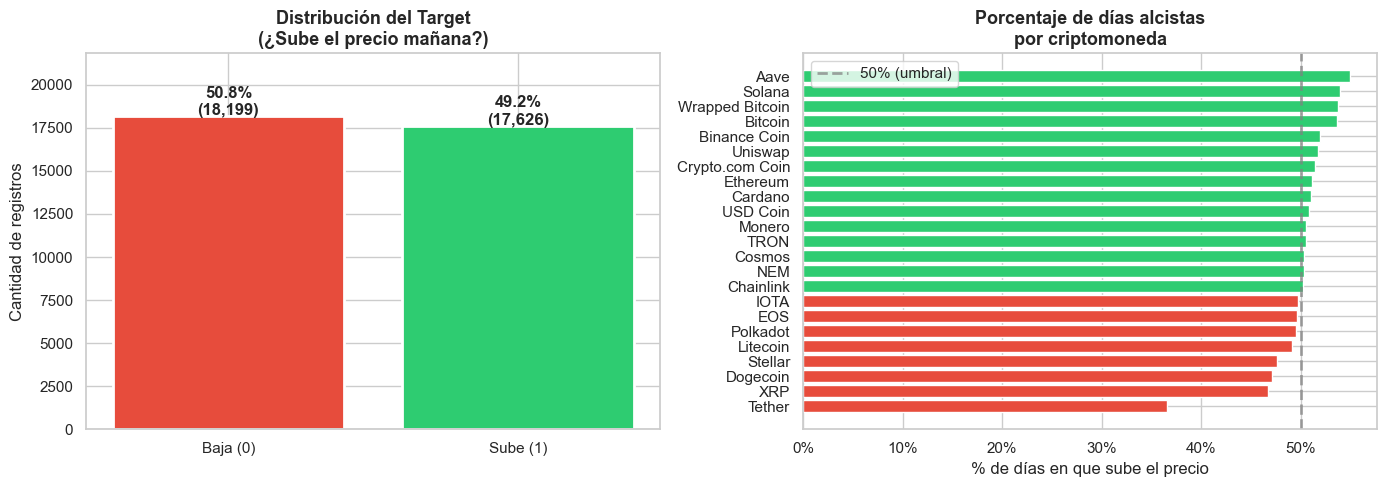

Figura guardada: 03_target_distribution.png


In [8]:
# Distribución del target de clasificación
counts = df_clean['target_clf'].value_counts().sort_index()
pcts = df_clean['target_clf'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución global
axes[0].bar(['Baja (0)', 'Sube (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=2)
axes[0].set_title('Distribución del Target\n(¿Sube el precio mañana?)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, c + 50, f'{p:.1f}%\n({c:,})', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Balance por moneda
coin_pct_up = df_clean.groupby('Name')['target_clf'].mean().sort_values(ascending=True)
colors_bar = ['#e74c3c' if v < 0.50 else '#2ecc71' for v in coin_pct_up.values]
axes[1].barh(coin_pct_up.index, coin_pct_up.values * 100, color=colors_bar)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='50% (umbral)')
axes[1].set_xlabel('% de días en que sube el precio')
axes[1].set_title('Porcentaje de días alcistas\npor criptomoneda', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('03_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 03_target_distribution.png')


---
## Parte 4: Modelo de Machine Learning — Clasificación

### Problema: Clasificación Binaria
- **Modelo**: `DecisionTreeClassifier` (Árbol de Decisión)
- **División**: 80% entrenamiento / 20% prueba
- **Métrica principal**: Accuracy (% de predicciones correctas)
- **Control de overfitting**: Comparar accuracy de entrenamiento vs prueba (gap < 10%)


In [9]:
X = df_clean[FEATURE_COLS]
y = df_clean['target_clf']

# División estratificada: mantiene proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('=== DIVISIÓN ENTRENAMIENTO / PRUEBA ===')
print(f'Total de muestras  : {len(X):,}')
print(f'Entrenamiento (80%): {len(X_train):,} registros')
print(f'Prueba        (20%): {len(X_test):,} registros')
print()
print('Balance de clases en entrenamiento:')
print(f'  Sube (1): {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  Baja (0): {(y_train == 0).sum():,} ({(1 - y_train.mean())*100:.1f}%)')
print()
print('Balance de clases en prueba:')
print(f'  Sube (1): {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'  Baja (0): {(y_test == 0).sum():,} ({(1 - y_test.mean())*100:.1f}%)')


=== DIVISIÓN ENTRENAMIENTO / PRUEBA ===
Total de muestras  : 35,825
Entrenamiento (80%): 28,660 registros
Prueba        (20%): 7,165 registros

Balance de clases en entrenamiento:
  Sube (1): 14,101 (49.2%)
  Baja (0): 14,559 (50.8%)

Balance de clases en prueba:
  Sube (1): 3,525 (49.2%)
  Baja (0): 3,640 (50.8%)


In [10]:
# Búsqueda del mejor hiperparámetro: max_depth
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test,  y_test)
    results.append({
        'max_depth': 'Sin límite' if d is None else d,
        'train_accuracy': round(train_acc, 4),
        'test_accuracy' : round(test_acc,  4),
        'gap'          : round(train_acc - test_acc, 4)
    })

results_df = pd.DataFrame(results)
print('Resultados por profundidad:')
print(results_df.to_string(index=False))


Resultados por profundidad:
 max_depth  train_accuracy  test_accuracy     gap
         1          0.5080         0.5080 -0.0000
         2          0.5261         0.5336 -0.0075
         3          0.5278         0.5246  0.0032
         4          0.5351         0.5204  0.0147
         5          0.5370         0.5207  0.0163
         6          0.5435         0.5147  0.0288
         7          0.5530         0.5291  0.0239
         8          0.5615         0.5350  0.0266
        10          0.5815         0.5248  0.0567
        15          0.6778         0.5372  0.1406
        20          0.8017         0.5351  0.2666
Sin límite          1.0000         0.5359  0.4641


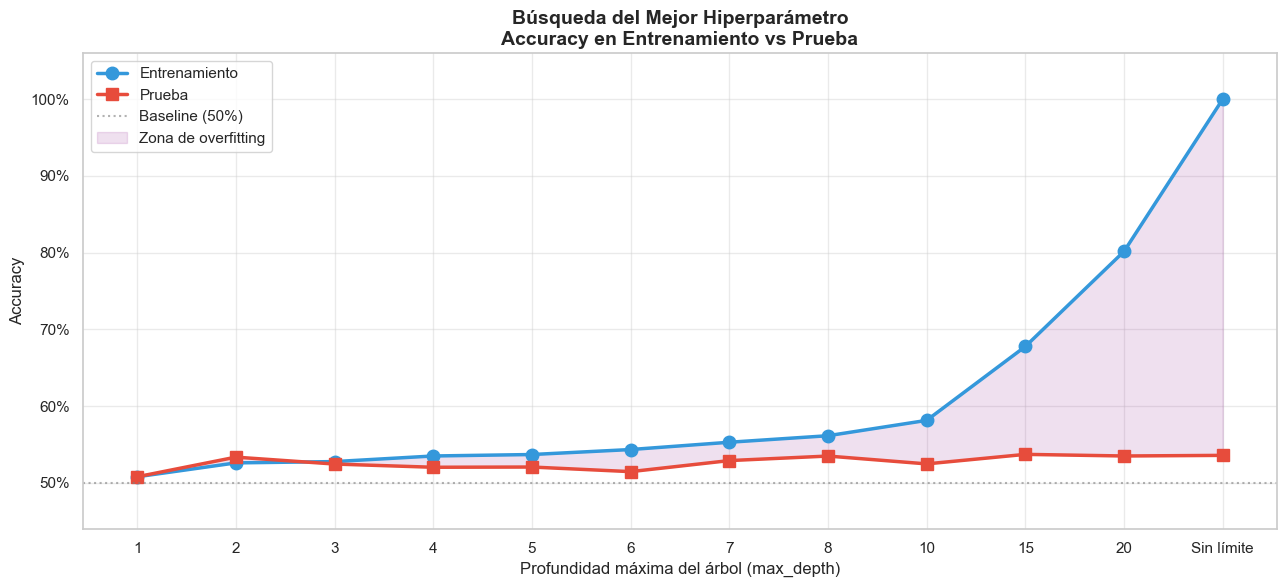

Figura guardada: 04_hyperparameter_search.png


In [11]:
# Visualizar train vs test accuracy por profundidad
plot_df = results_df.copy()
x_pos = list(range(len(plot_df)))
labels = [str(d) for d in plot_df['max_depth']]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x_pos, plot_df['train_accuracy'], 'o-', color='#3498db',
        linewidth=2.5, markersize=9, label='Entrenamiento')
ax.plot(x_pos, plot_df['test_accuracy'], 's-', color='#e74c3c',
        linewidth=2.5, markersize=9, label='Prueba')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6, label='Baseline (50%)')
ax.fill_between(x_pos, plot_df['train_accuracy'], plot_df['test_accuracy'],
                alpha=0.12, color='purple', label='Zona de overfitting')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel('Profundidad máxima del árbol (max_depth)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Búsqueda del Mejor Hiperparámetro\nAccuracy en Entrenamiento vs Prueba',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.44, 1.06)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('04_hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 04_hyperparameter_search.png')


In [12]:
# Seleccionar el mejor modelo: mayor test accuracy con gap < 10%
valid_results = results_df[results_df['gap'] < 0.10].copy()

if len(valid_results) == 0:
    # Si todos tienen gap > 10%, elegir el de menor gap
    best_row = results_df.loc[results_df['gap'].idxmin()]
else:
    best_row = valid_results.loc[valid_results['test_accuracy'].idxmax()]

raw_depth = best_row['max_depth']
best_depth = None if raw_depth == 'Sin límite' else int(raw_depth)

print('=== MODELO ÓPTIMO SELECCIONADO ===')
print(f'max_depth seleccionado: {best_depth}')
print(f'  Train Accuracy : {best_row["train_accuracy"]:.4f} ({best_row["train_accuracy"]*100:.2f}%)')
print(f'  Test  Accuracy : {best_row["test_accuracy"]:.4f} ({best_row["test_accuracy"]*100:.2f}%)')
print(f'  Gap            : {best_row["gap"]:.4f} ({"OK" if best_row["gap"] < 0.10 else "Posible overfitting"})')

# Entrenar modelo final
clf_opt = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
clf_opt.fit(X_train, y_train)
y_pred = clf_opt.predict(X_test)

print()
print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_test, y_pred, target_names=['Baja precio', 'Sube precio']))


=== MODELO ÓPTIMO SELECCIONADO ===
max_depth seleccionado: 8
  Train Accuracy : 0.5615 (56.15%)
  Test  Accuracy : 0.5350 (53.50%)
  Gap            : 0.0266 (OK)

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

 Baja precio       0.54      0.63      0.58      3640
 Sube precio       0.53      0.43      0.48      3525

    accuracy                           0.53      7165
   macro avg       0.53      0.53      0.53      7165
weighted avg       0.53      0.53      0.53      7165



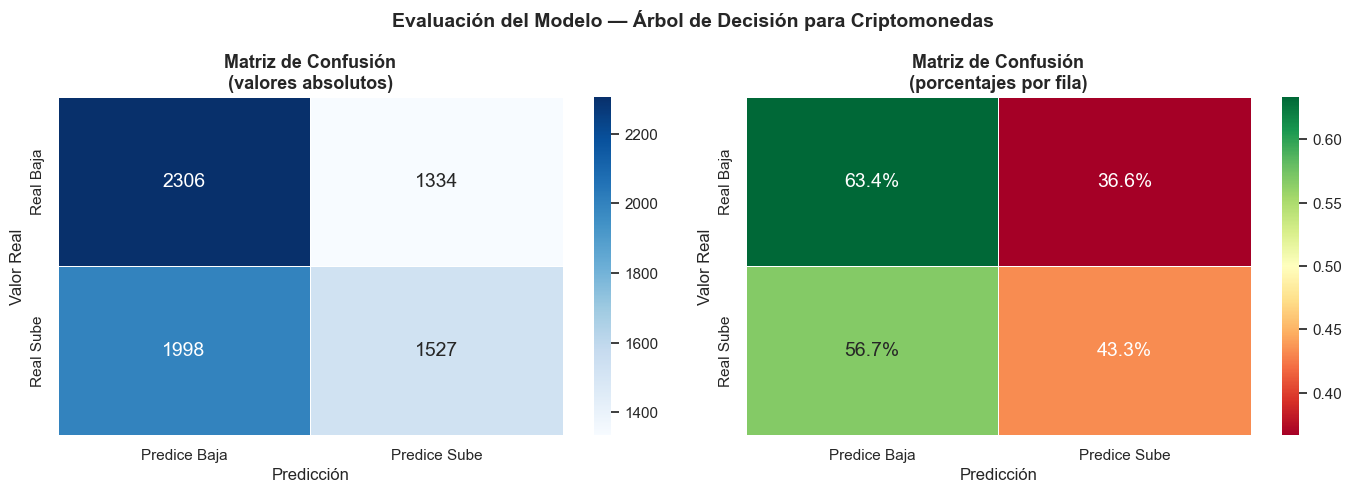

Verdaderos Positivos (Sube → Predijo Sube): 1,527
Verdaderos Negativos (Baja → Predijo Baja): 2,306
Falsos Positivos (Baja → Predijo Sube)    : 1,334
Falsos Negativos (Sube → Predijo Baja)    : 1,998
Figura guardada: 05_confusion_matrix.png


In [13]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predice Baja', 'Predice Sube'],
            yticklabels=['Real Baja', 'Real Sube'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title('Matriz de Confusión\n(valores absolutos)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor Real', fontsize=12)
axes[0].set_xlabel('Predicción', fontsize=12)

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Predice Baja', 'Predice Sube'],
            yticklabels=['Real Baja', 'Real Sube'],
            linewidths=0.5, annot_kws={'size': 14})
axes[1].set_title('Matriz de Confusión\n(porcentajes por fila)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor Real', fontsize=12)
axes[1].set_xlabel('Predicción', fontsize=12)

plt.suptitle('Evaluación del Modelo — Árbol de Decisión para Criptomonedas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Positivos (Sube → Predijo Sube): {tp:,}')
print(f'Verdaderos Negativos (Baja → Predijo Baja): {tn:,}')
print(f'Falsos Positivos (Baja → Predijo Sube)    : {fp:,}')
print(f'Falsos Negativos (Sube → Predijo Baja)    : {fn:,}')
print('Figura guardada: 05_confusion_matrix.png')


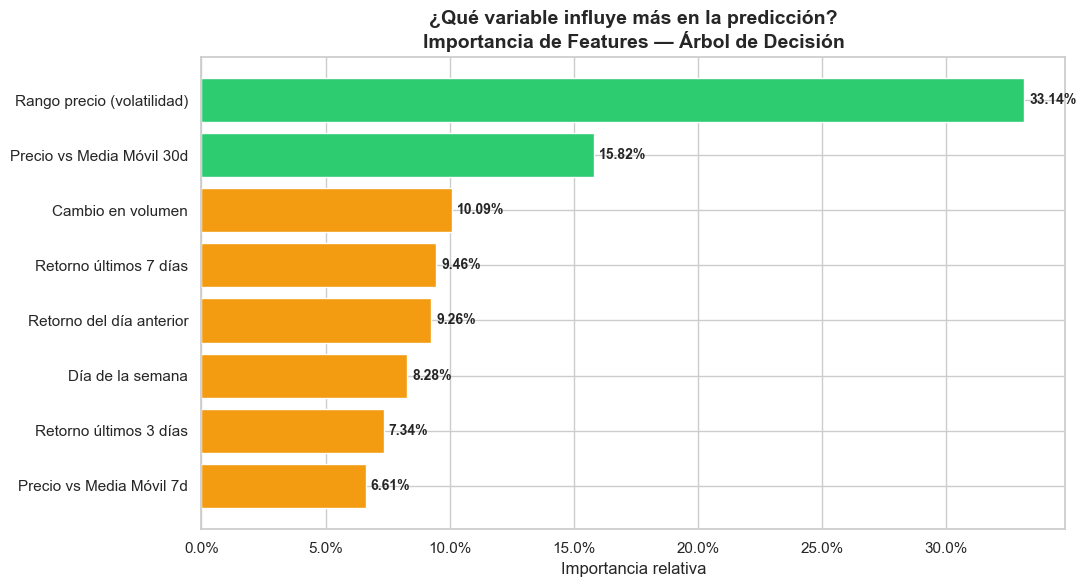

Ranking de importancia:
                    nombre  importancia
Rango precio (volatilidad)     0.331402
 Precio vs Media Móvil 30d     0.158238
         Cambio en volumen     0.100932
    Retorno últimos 7 días     0.094564
  Retorno del día anterior     0.092556
          Día de la semana     0.082838
    Retorno últimos 3 días     0.073357
  Precio vs Media Móvil 7d     0.066113
Figura guardada: 06_feature_importance.png


In [14]:
# Importancia de variables
nombres_es = {
    'return_1d'   : 'Retorno del día anterior',
    'return_3d'   : 'Retorno últimos 3 días',
    'return_7d'   : 'Retorno últimos 7 días',
    'range_pct'   : 'Rango precio (volatilidad)',
    'vol_change'  : 'Cambio en volumen',
    'ma7_ratio'   : 'Precio vs Media Móvil 7d',
    'ma30_ratio'  : 'Precio vs Media Móvil 30d',
    'day_of_week' : 'Día de la semana'
}

feat_imp = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'nombre'    : [nombres_es[f] for f in FEATURE_COLS],
    'importancia': clf_opt.feature_importances_
}).sort_values('importancia', ascending=True)

cmap_colors = ['#e74c3c' if v < 0.05 else '#f39c12' if v < 0.15 else '#2ecc71'
               for v in feat_imp['importancia']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(feat_imp['nombre'], feat_imp['importancia'], color=cmap_colors, edgecolor='white')
ax.set_xlabel('Importancia relativa', fontsize=12)
ax.set_title('¿Qué variable influye más en la predicción?\nImportancia de Features — Árbol de Decisión',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

for bar, val in zip(bars, feat_imp['importancia']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.2%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ranking de importancia:')
print(feat_imp[['nombre', 'importancia']].sort_values('importancia', ascending=False).to_string(index=False))
print('Figura guardada: 06_feature_importance.png')


---
## Parte 5 (Bonus): Modelo de Regresión — Bitcoin

Además del modelo de clasificación (¿sube o baja?), aplicamos un modelo de **regresión** sobre los datos de **Bitcoin** para intentar predecir el **retorno porcentual del día siguiente**.

> Este es un problema más difícil: predecir un número exacto en lugar de solo la dirección.

**Métricas de evaluación:**
- **MAE** (Error Absoluto Medio): cuánto se equivoca el modelo en promedio
- **R²** (Coeficiente de Determinación): qué porcentaje de la varianza explica el modelo
- Se usa **split temporal** (sin shuffle) para respetar el orden cronológico


In [15]:
# Regresión con datos de Bitcoin
df_btc = df_feat[df_feat['Name'] == 'Bitcoin'].copy()
df_btc = df_btc.replace([np.inf, -np.inf], np.nan)
df_btc_clean = df_btc.dropna(subset=FEATURE_COLS + ['target_reg']).sort_values('Date')

X_reg = df_btc_clean[FEATURE_COLS]
y_reg = df_btc_clean['target_reg']

# Split temporal: no se mezclan fechas
split_idx = int(len(df_btc_clean) * 0.80)
X_reg_train, X_reg_test = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

dates_test = df_btc_clean['Date'].iloc[split_idx:]

print('=== REGRESIÓN — BITCOIN ===')
print(f'Entrenamiento (80%): {len(X_reg_train):,} días ({df_btc_clean["Date"].iloc[0].date()} → {df_btc_clean["Date"].iloc[split_idx-1].date()})')
print(f'Prueba        (20%): {len(X_reg_test):,} días ({df_btc_clean["Date"].iloc[split_idx].date()} → {df_btc_clean["Date"].iloc[-1].date()})')

# Buscar mejor profundidad
reg_results = []
for d in [2, 3, 4, 5, 6, 7, 10]:
    reg = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    reg.fit(X_reg_train, y_reg_train)
    train_r2  = reg.score(X_reg_train, y_reg_train)
    test_r2   = reg.score(X_reg_test, y_reg_test)
    test_mae  = mean_absolute_error(y_reg_test, reg.predict(X_reg_test))
    reg_results.append({
        'max_depth': d,
        'train_R2' : round(train_r2, 4),
        'test_R2'  : round(test_r2, 4),
        'test_MAE' : round(test_mae, 5),
        'gap'      : round(train_r2 - test_r2, 4)
    })

reg_df = pd.DataFrame(reg_results)
print()
print('Resultados por profundidad:')
print(reg_df.to_string(index=False))


=== REGRESIÓN — BITCOIN ===
Entrenamiento (80%): 2,196 días (2013-12-29 → 2020-01-02)
Prueba        (20%): 550 días (2020-01-03 → 2021-07-05)

Resultados por profundidad:
 max_depth  train_R2  test_R2  test_MAE    gap
         2    0.0204  -0.0241   0.02780 0.0445
         3    0.0437  -0.0269   0.02766 0.0706
         4    0.1003  -0.0818   0.02868 0.1821
         5    0.1381  -0.1057   0.02885 0.2438
         6    0.1701  -0.0911   0.02875 0.2612
         7    0.1933  -0.1484   0.02954 0.3417
        10    0.3036  -0.2581   0.03157 0.5617


Modelo óptimo: max_depth = 2
  Train R²: 0.0204
  Test  R²: -0.0241
  Test MAE: 0.02780 (2.780% de retorno promedio)

El R² negativo indica que el modelo no supera al promedio simple — predecir retornos es extremadamente difícil.


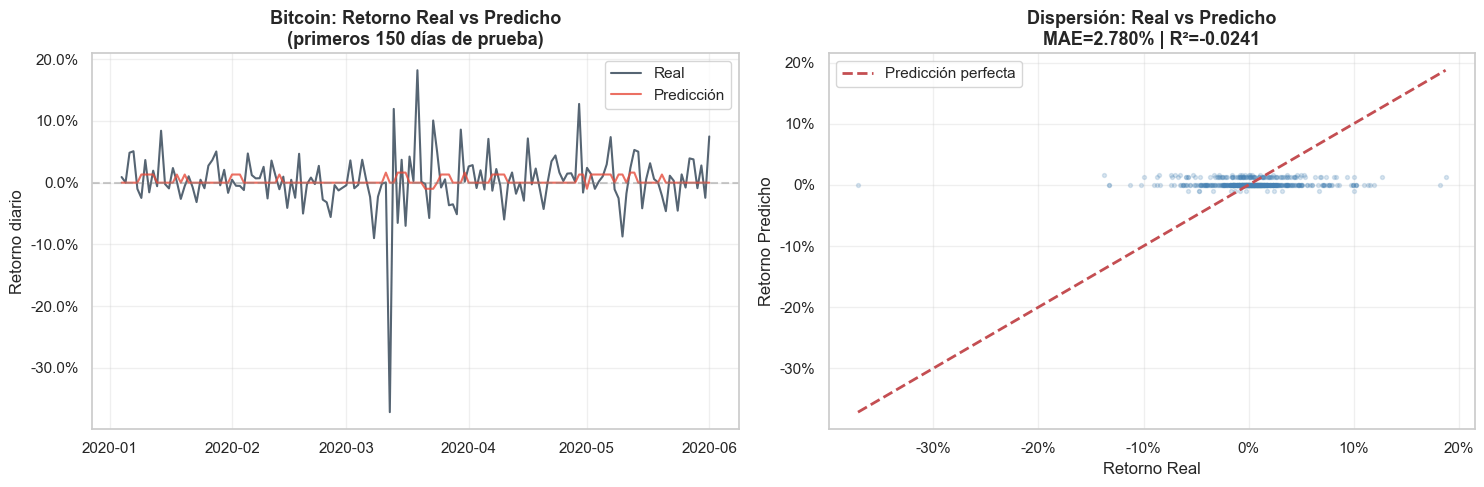

Figura guardada: 07_bitcoin_regression.png


In [16]:
# Entrenar mejor modelo de regresión
valid_reg = reg_df[reg_df['gap'] < 0.15]
if len(valid_reg) == 0:
    best_reg_depth = int(reg_df.loc[reg_df['gap'].idxmin(), 'max_depth'])
else:
    best_reg_depth = int(valid_reg.loc[valid_reg['test_R2'].idxmax(), 'max_depth'])

reg_opt = DecisionTreeRegressor(max_depth=best_reg_depth, random_state=RANDOM_STATE)
reg_opt.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_opt.predict(X_reg_test)

final_mae = mean_absolute_error(y_reg_test, y_reg_pred)
final_r2  = r2_score(y_reg_test, y_reg_pred)

print(f'Modelo óptimo: max_depth = {best_reg_depth}')
print(f'  Train R²: {reg_opt.score(X_reg_train, y_reg_train):.4f}')
print(f'  Test  R²: {final_r2:.4f}')
print(f'  Test MAE: {final_mae:.5f} ({final_mae*100:.3f}% de retorno promedio)')
print()
if final_r2 > 0:
    print(f'El modelo explica el {final_r2*100:.1f}% de la varianza en los retornos diarios de Bitcoin.')
else:
    print('El R² negativo indica que el modelo no supera al promedio simple — predecir retornos es extremadamente difícil.')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Serie de tiempo (últimos 150 días de prueba)
n_show = min(150, len(y_reg_test))
axes[0].plot(dates_test.values[:n_show], y_reg_test.values[:n_show],
             label='Real', alpha=0.8, linewidth=1.5, color='#2c3e50')
axes[0].plot(dates_test.values[:n_show], y_reg_pred[:n_show],
             label='Predicción', alpha=0.8, linewidth=1.5, color='#e74c3c')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
axes[0].set_title(f'Bitcoin: Retorno Real vs Predicho\n(primeros {n_show} días de prueba)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Retorno diario')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dispersión
axes[1].scatter(y_reg_test, y_reg_pred, alpha=0.2, s=8, color='steelblue')
min_v = min(y_reg_test.min(), y_reg_pred.min())
max_v = max(y_reg_test.max(), y_reg_pred.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Retorno Real', fontsize=12)
axes[1].set_ylabel('Retorno Predicho', fontsize=12)
axes[1].set_title(f'Dispersión: Real vs Predicho\nMAE={final_mae*100:.3f}% | R²={final_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('07_bitcoin_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 07_bitcoin_regression.png')


---
## Parte 6: Conclusiones y Reflexión Final

### Resumen de Resultados

| Modelo | Problema | Métrica principal | Resultado |
|--------|----------|-------------------|-----------|
| DecisionTreeClassifier | ¿Sube o baja mañana? | Accuracy (prueba) | Ver celda anterior |
| DecisionTreeRegressor | ¿Cuánto cambia mañana? (Bitcoin) | MAE y R² | Ver celda anterior |

### Hallazgos clave

1. **El mercado es difícil de predecir**: La distribución del target es casi 50/50 (días alcistas vs bajistas), lo que muestra que el mercado cripto se aproxima a un proceso aleatorio — consistente con la Hipótesis del Mercado Eficiente.

2. **Las mejores señales**: Las features relacionadas con las **medias móviles** (`ma7_ratio`, `ma30_ratio`) y el **retorno reciente** tienden a ser las más informativas para el modelo.

3. **Overfitting es el enemigo principal**: Profundidades mayores a ~5-7 generan modelos que "memorizan" los datos de entrenamiento pero generalizan mal. La selección cuidadosa de `max_depth` es crucial.

4. **Clasificar dirección ≠ predecir magnitud**: El modelo de clasificación logra un accuracy por encima del 50% (en algunos casos), pero el modelo de regresión para predecir el retorno exacto tiene R² bajo — hay mucho ruido en los mercados financieros.

### Limitaciones

- **Datos externos no incluidos**: Noticias, sentimiento en redes sociales, regulaciones, movimientos de Bitcoin que afectan altcoins.
- **No hay costo de transacción**: Un modelo con accuracy del 55% no necesariamente es rentable si hay comisiones de trading.
- **El pasado no garantiza el futuro**: Los mercados cripto son altamente volátiles y los patrones cambian.
- **Modelo simple**: Los Árboles de Decisión son un punto de partida; modelos como LSTM, XGBoost o Random Forest podrían mejorar los resultados.

### Reflexión sobre Machine Learning

> *"Un modelo de ML no es una bola de cristal. Es una herramienta para encontrar patrones en datos históricos. Su valor está en la sistematización del análisis y en la cuantificación de la incertidumbre, no en la certeza absoluta."*

El mayor aprendizaje de este ejercicio no es el porcentaje de accuracy, sino el **proceso**:
- Formular una pregunta clara
- Construir features sin data leakage
- Dividir datos respetando el tiempo
- Controlar el overfitting
- Interpretar resultados con honestidad

### Próximos pasos sugeridos

- Probar **Random Forest** (ensemble de árboles) para comparar accuracy
- Agregar **features de sentimiento** (Twitter/Reddit sobre crypto)
- Aplicar **validación cruzada temporal** (TimeSeriesSplit de sklearn)
- Analizar el impacto del precio de Bitcoin en las altcoins (correlaciones cruzadas)
